In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal,Annotated
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage,HumanMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv

c:\CODE\Personal\AI-and-ML\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

True

In [3]:
class EvaluationSchema(BaseModel):
    evaluation:Literal['approved','need_improvement']= Field(...,description="Final Evaluation of the tweet.")
    feedback: str =Field(...,description="Constructive feedback for the tweet.")
    score: int = Field(...,description="TOtal score for the rubric (0-5)")

In [4]:
generator_llm= ChatGoogleGenerativeAI(model="gemini-2.5-flash")

evaluator_llm= ChatGroq(model="llama-3.3-70b-versatile").with_structured_output(EvaluationSchema)

optimizer_llm= ChatGroq(model="llama-3.3-70b-versatile")




In [5]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved','need_improvement']
    feeback: str
    iteration: int
    max_iteration: int

In [6]:
def generate_tweet(state:TweetState):
    
    messages= [
        SystemMessage(content='You area funny and clever Twitter/X influencer.'),
        HumanMessage(content=f''' 
                     Write a short, original and hilarious tweet on the topic: "{state['topic']}".
                     
                     Rules:
                     -Do NOT use question-answer format.
                     -Max 200 characters.
                     -Use Observational humar, irony, sarcsm or cultural references.
                     -Think in meme logic, punchlines, or relatable takes.
                     -Use simple, day to day english.
                     -THis is version {state['iteration']+1}.
                     ''')
    ]
    
    response=generator_llm.invoke(messages).content
    
    return {'tweet':response}

def evaluate_tweet(state:TweetState):
    
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    
    response= evaluator_llm.invoke(messages)
    
    return {'evaluation':response.evaluation,'feedback':response.feedback}


def optimize_tweet(state:TweetState):
    
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    
    response= optimizer_llm.invoke(messages).content
    iteration = state['iteration']+1
    
    return {'tweet':response, 'iteration':iteration}



In [7]:
def route_evaluation(state:TweetState):
    if state['evaluation']=='approved' or state['iteration']==state['max_iteration']:
        return 'approved'
    
    else:
        return 'need_improvement'

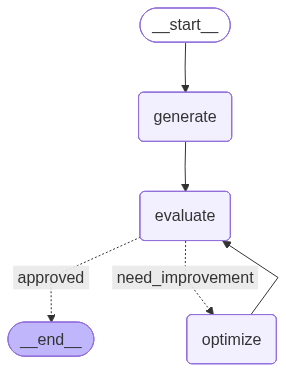

In [8]:
graph= StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START, "generate")
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation, {'approved':END, 'need_improvement':'optimize'})
graph.add_edge('optimize','evaluate')

workflow= graph.compile()
workflow



In [9]:
initial_state = {
    'topic': 'Indian_railways',
    'iteration':1,
    'max_iteration':5
}

workflow.invoke(initial_state)

{'topic': 'Indian_railways',
 'tweet': "Indian Railways: My train is so late, I've already finished my novel, learned a new language, and questioned all my life choices. Still waiting. #TrainLife #IndianRailways",
 'evaluation': 'approved',
 'iteration': 1,
 'max_iteration': 5}